In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [19]:
longi = pd.read_csv('oasis_longitudinal.csv')
cross = pd.read_csv('oasis_cross-sectional.csv')

longi['SES'] = longi['SES'].fillna(longi['SES'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
cross['SES'] = cross['SES'].fillna(cross['SES'].median())
cross['MMSE'] = cross['MMSE'].fillna(cross['MMSE'].median())
cross['Educ'] = cross['Educ'].fillna(cross['Educ'].median())
cross['CDR'] = cross['CDR'].fillna(cross['CDR'].median())

cross_renamed = cross.rename(columns={'Educ': 'EDUC'})

features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X_longi = longi[features].fillna(longi.median(numeric_only=True))
y_longi = longi['CDR'].astype(str)
X_cross = cross_renamed[features].fillna(longi.median(numeric_only=True))
y_cross = cross_renamed['CDR'].astype(str)
longi.isna().sum()

Subject ID    0
MRI ID        0
Group         0
Visit         0
MR Delay      0
Sex           0
Hand          0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
dtype: int64

In [5]:
columnas_comunes = ['ID', 'Sex', 'Age', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
longi_renamed = longi.rename(columns={'EDUC': 'Educ', 'Subject ID': 'ID'})
df = pd.concat([cross[columnas_comunes], longi_renamed[columnas_comunes]], ignore_index=True)
features = ['Sex', 'Age', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
Xdf = df[features].fillna(longi.median(numeric_only=True))
ydf = df['CDR'].astype(str)
df.isna().sum()

ID      0
Sex     0
Age     0
SES     0
MMSE    0
CDR     0
eTIV    0
nWBV    0
ASF     0
dtype: int64

/tmp/ipykernel_11074/1285434075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CDR', data=longi, palette='viridis')


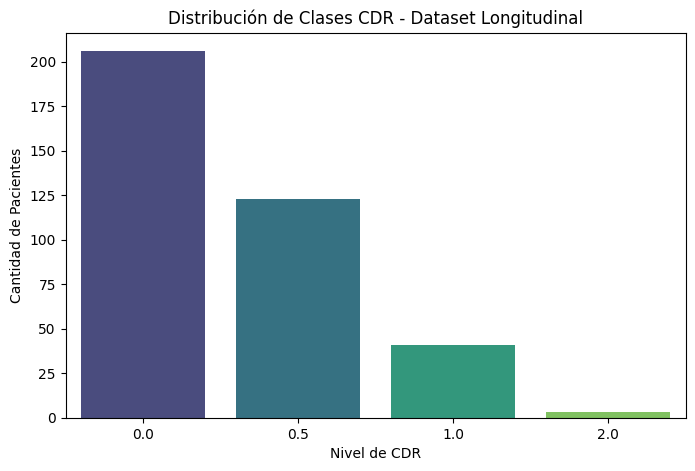

CDR
0.0    55.227882
0.5    32.975871
1.0    10.991957
2.0     0.804290
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='CDR', data=longi, palette='viridis')
plt.title("Distribución de Clases CDR - Dataset Longitudinal")
plt.xlabel("Nivel de CDR")
plt.ylabel("Cantidad de Pacientes")
plt.show()

# Resumen de desbalance para el informe
print(longi['CDR'].value_counts(normalize=True) * 100)

In [7]:
conteo_clases = longi['CDR'].value_counts().sort_index()
proporciones = longi['CDR'].value_counts(normalize=True).sort_index() * 100

# Presentación de resultados
print("Distribución de Clases - Set Longitudinal:")
for cdr, total in conteo_clases.items():
    print(f"CDR {cdr}: {total} pacientes ({proporciones[cdr]:.2f}%)")

Distribución de Clases - Set Longitudinal:
CDR 0.0: 206 pacientes (55.23%)
CDR 0.5: 123 pacientes (32.98%)
CDR 1.0: 41 pacientes (10.99%)
CDR 2.0: 3 pacientes (0.80%)


In [8]:
# Diccionario para almacenar los resultados del testeo
# Selección de atributos y objetivo

# Imputación de datos faltantes (necesaria antes del testeo)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

test_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

for i in range(10):
    # Paso A: Partición 80/20 con semilla (random_state) variable
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=i)
    
    # Paso B: Escalamiento (Ajustado solo en entrenamiento para evitar filtración) [5]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Paso C: Entrenamiento del modelo (ejemplo con k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    
    # Paso D: Predicción sobre el set de prueba (el testeo real)
    y_pred = knn.predict(X_test_scaled)
    
    # Paso E: Registro de métricas
    test_metrics['acc'].append(accuracy_score(y_test, y_pred))
    # Usamos 'macro' por el desbalance de clases (CDR 2 tiene muy pocos ejemplos) [2, 6]
    test_metrics['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    test_metrics['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    test_metrics['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

print(f"--- RESULTADOS FINALES DEL TESTEO (Longitudinal) ---")
print(f"Accuracy:  {np.mean(test_metrics['acc']):.4f} ± {np.std(test_metrics['acc']):.4f}")
print(f"Precision: {np.mean(test_metrics['prec']):.4f} ± {np.std(test_metrics['prec']):.4f}")
print(f"Recall:    {np.mean(test_metrics['rec']):.4f} ± {np.std(test_metrics['rec']):.4f}")
print(f"F1-Score:  {np.mean(test_metrics['f1']):.4f} ± {np.std(test_metrics['f1']):.4f}")


--- RESULTADOS FINALES DEL TESTEO (Longitudinal) ---
Accuracy:  0.6747 ± 0.0414
Precision: 0.5983 ± 0.1097
Recall:    0.5427 ± 0.0942
F1-Score:  0.5480 ± 0.0931


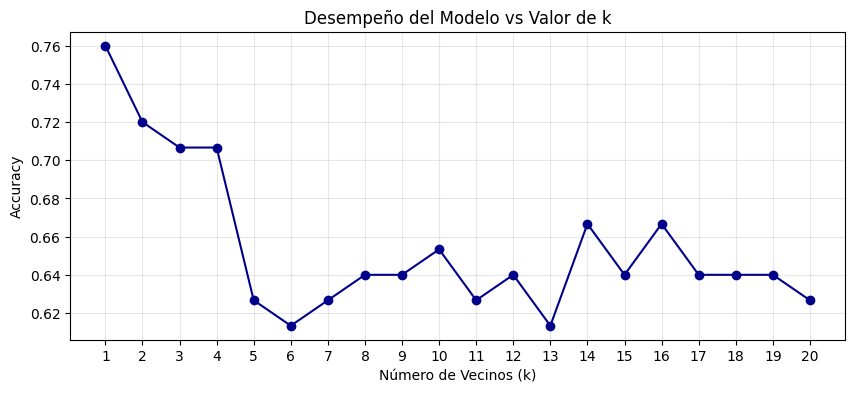

In [9]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Búsqueda de k óptimo
k_values = range(1, 21)
mean_acc = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    # Usamos una partición 80/20 para la curva de validación
    xt, xv, yt, yv = train_test_split(X_imputed, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    xt_s = sc.fit_transform(xt)
    xv_s = sc.transform(xv)
    knn_temp.fit(xt_s, yt)
    mean_acc.append(accuracy_score(yv, knn_temp.predict(xv_s)))

plt.figure(figsize=(10, 4))
plt.plot(k_values, mean_acc, marker='o', color='darkblue')
plt.title("Desempeño del Modelo vs Valor de k")
plt.xlabel("Número de Vecinos (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

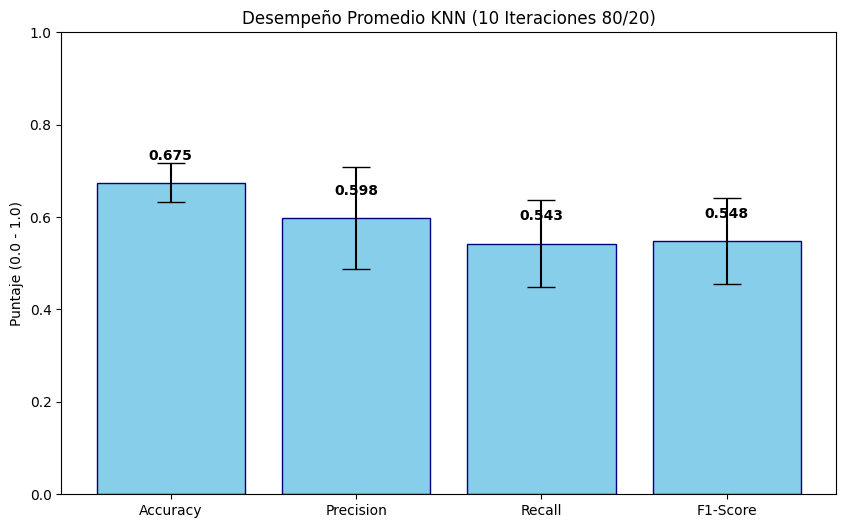

In [10]:
# Diccionario para almacenar métricas de las 10 iteraciones
metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for i in range(10):
    # Partición independiente
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=i)
    
    # Escalamiento (Vital para KNN por basarse en distancias)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Entrenamiento con k=5
    knn_final = KNeighborsClassifier(n_neighbors=5)
    knn_final.fit(X_train_s, y_train)
    y_pred = knn_final.predict(X_test_s)
    
    # Cálculo de métricas (promedio 'macro' por desbalance y multiclase)
    metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['Precision'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['Recall'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['F1-Score'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

# Visualización de Métricas con Error (Media ± DE)
labels = list(metrics.keys())
means = [np.mean(metrics[m]) for m in labels]
stds = [np.std(metrics[m]) for m in labels]

plt.figure(figsize=(10, 6))
plt.bar(labels, means, yerr=stds, capsize=10, color='skyblue', edgecolor='navy')
plt.title("Desempeño Promedio KNN (10 Iteraciones 80/20)")
plt.ylabel("Puntaje (0.0 - 1.0)")
plt.ylim(0, 1)
for i, v in enumerate(means):
    plt.text(i, v + 0.05, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

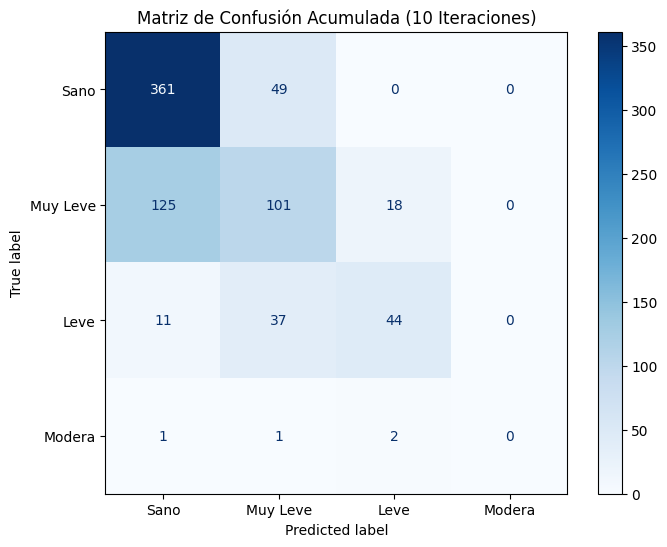

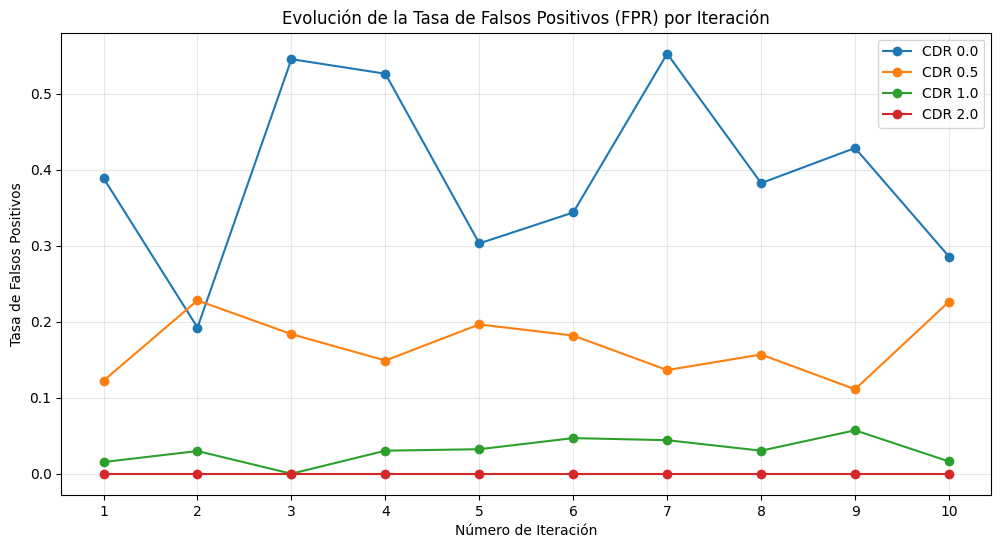

In [ ]:
clases = ['0.0', '0.5', '1.0', '2.0']
# Imputación y configuración inicial
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Listas para almacenar resultados
matrices_confusion = []
fpr_por_iteracion = {clase: [] for clase in clases}

# 2. Ejecución de las 10 validaciones independientes (80/20)
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=i)
    
    # Escalamiento
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo KNN (k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    
    # Matriz de confusión de la iteración
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    matrices_confusion.append(cm)
    
    # Cálculo de FPR por clase para esta iteración
    # FPR = FP / (FP + TN)
    for j, clase in enumerate(clases):
        fp = cm[:, j].sum() - cm[j, j]
        fn = cm[j, :].sum() - cm[j, j]
        tp = cm[j, j]
        tn = cm.sum() - (fp + fn + tp)
        
        tasa_fp = fp / (fp + tn) if (fp + tn) > 0 else 0
        fpr_por_iteracion[clase].append(tasa_fp)

# 3. Visualización 1: Matriz de Confusión Acumulada
cm_total = np.sum(matrices_confusion, axis=0)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_total, display_labels=['Sano', 'Muy Leve', 'Leve', 'Modera'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title("Matriz de Confusión Acumulada (10 Iteraciones)")
plt.show()

# 4. Visualización 2: Tasa de Falsos Positivos por Iteración
plt.figure(figsize=(12, 6))
for clase, valores in fpr_por_iteracion.items():
    plt.plot(range(1, 11), valores, marker='o', label=f"CDR {clase}")

plt.title("Evolución de la Tasa de Falsos Positivos (FPR) por Iteración")
plt.xlabel("Número de Iteración")
plt.ylabel("Tasa de Falsos Positivos")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

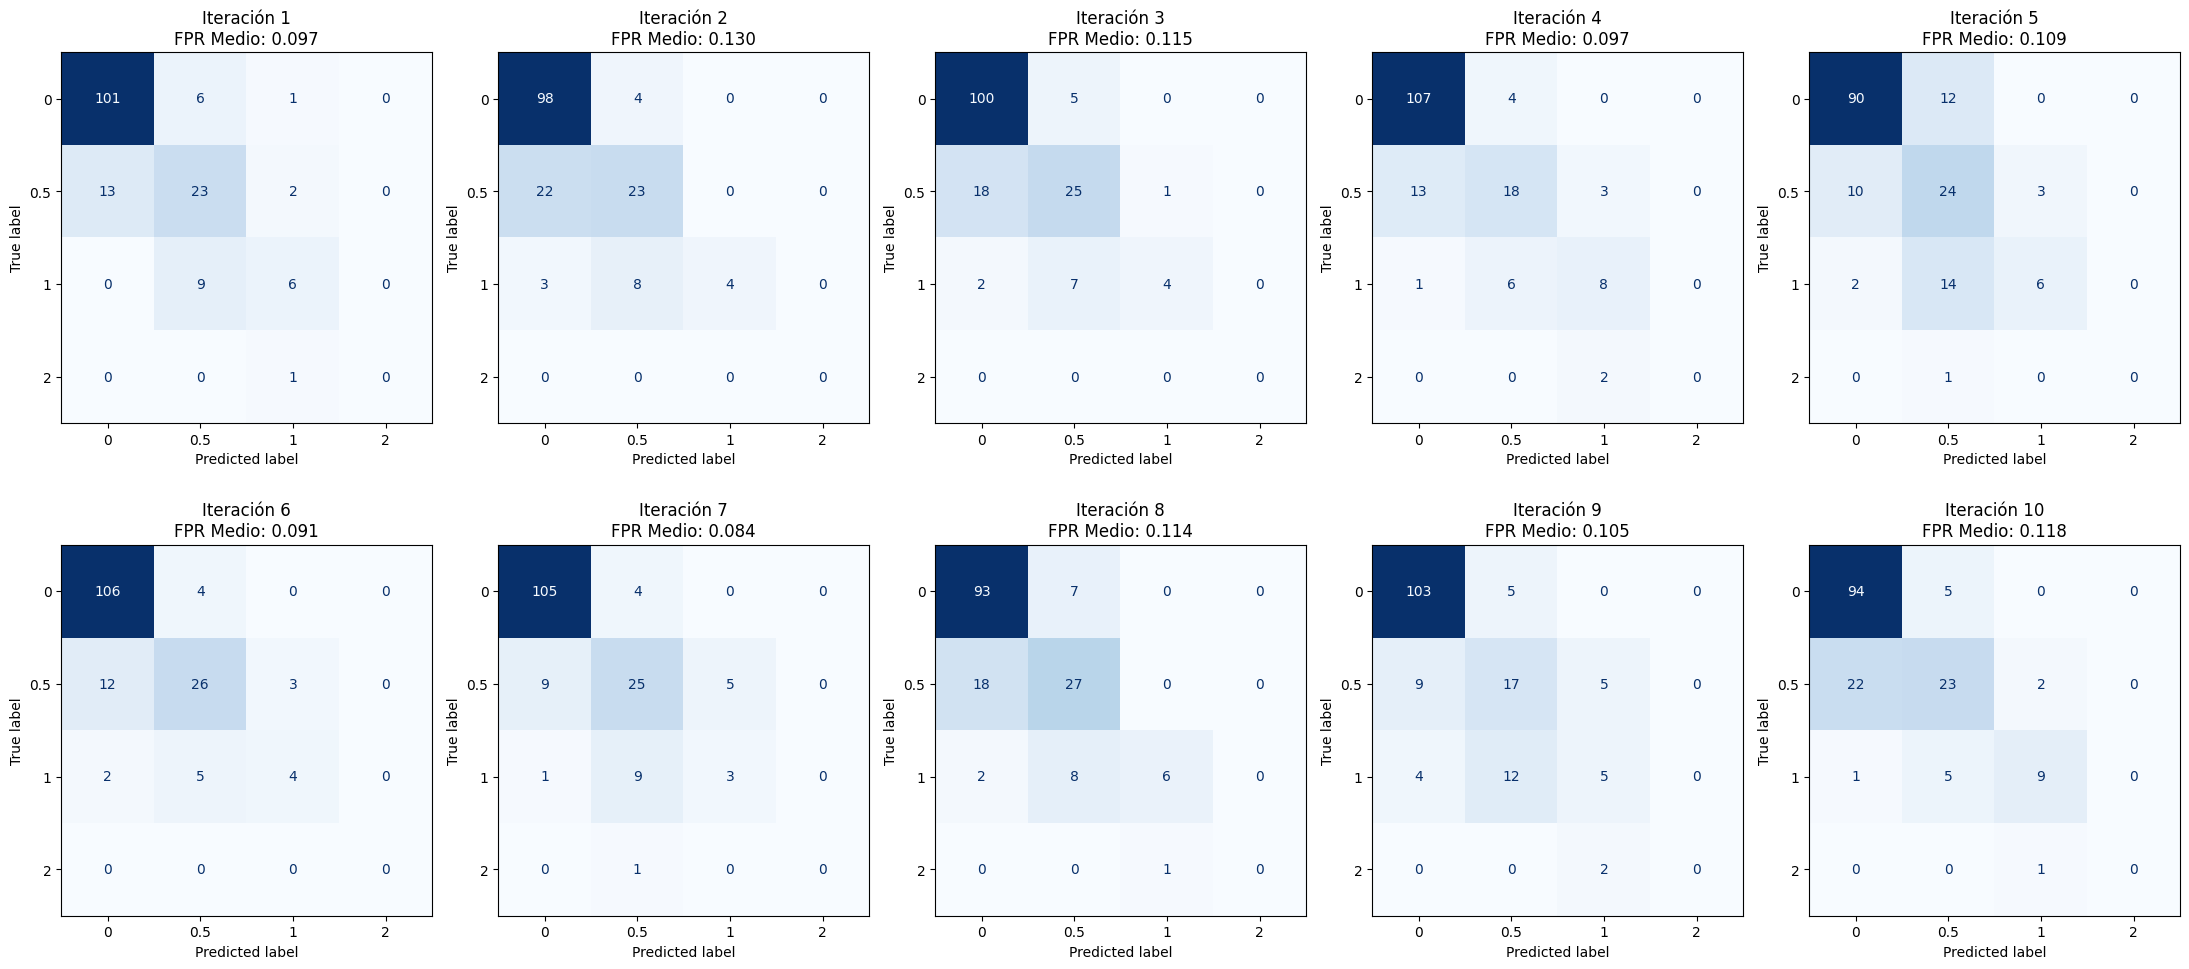


Tasa de Falsos Positivos (FPR) por Clase e Iteración:
              0.0       0.5       1.0  2.0
Iter 1   0.240741  0.120968  0.027211  0.0
Iter 2   0.416667  0.102564  0.000000  0.0
Iter 3   0.350877  0.101695  0.006711  0.0
Iter 4   0.274510  0.078125  0.034014  0.0
Iter 5   0.200000  0.216000  0.021429  0.0
Iter 6   0.269231  0.074380  0.019868  0.0
Iter 7   0.188679  0.113821  0.033557  0.0
Iter 8   0.322581  0.128205  0.006849  0.0
Iter 9   0.240741  0.129771  0.049645  0.0
Iter 10  0.365079  0.086957  0.020408  0.0


In [17]:
# Imputación de datos faltantes (SES y MMSE) [6]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(Xdf)

# Configuración del grid de visualización (2x5 para 10 iteraciones)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

# Almacén para FPR por iteración y clase [2]
fpr_results = []

# 2. Ejecución de las 10 validaciones independientes 80/20 [4]
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, ydf, test_size=0.2, random_state=i)
    
    # Escalamiento basado solo en entrenamiento [6, 7]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo KNN con k=5 [8]
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    
    # 3. Generación de la Matriz de Confusión por iteración [2, 9]
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    
    # 4. Cálculo de FPR por clase (FP / FP + TN) [2]
    fpr_iter = {}
    for j, clase in enumerate(clases):
        fp = cm[:, j].sum() - cm[j, j]
        fn = cm[j, :].sum() - cm[j, j]
        tp = cm[j, j]
        tn = cm.sum() - (fp + fn + tp)
        fpr_iter[clase] = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    fpr_results.append(fpr_iter)
    
    # Título de cada subplot con el FPR promedio de la iteración
    fpr_medio = np.mean(list(fpr_iter.values()))
    axes[i].set_title(f"Iteración {i+1}\nFPR Medio: {fpr_medio:.3f}")

plt.tight_layout()
plt.show()

# 5. Reporte tabular del FPR por iteración para el informe
fpr_df = pd.DataFrame(fpr_results)
fpr_df.index = [f"Iter {i+1}" for i in range(10)]
print("\nTasa de Falsos Positivos (FPR) por Clase e Iteración:")
print(fpr_df)

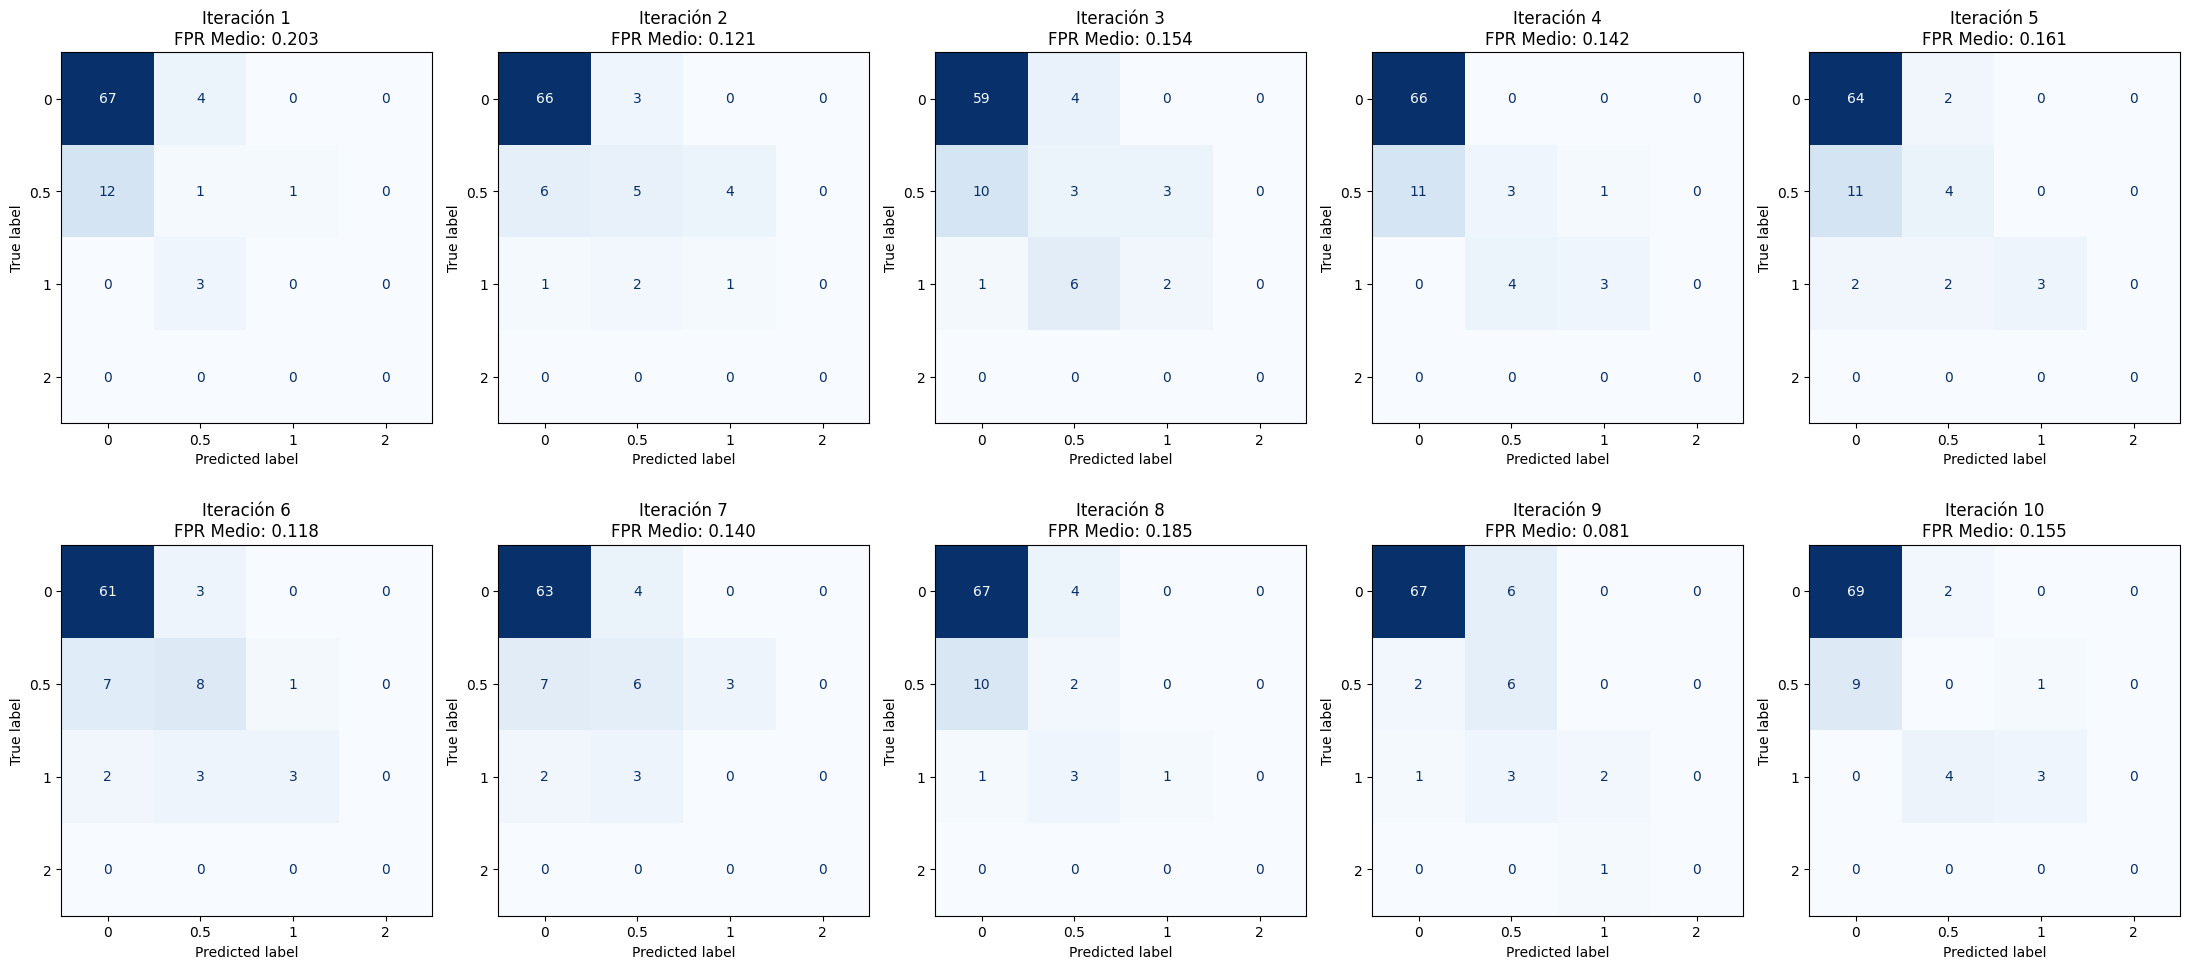


Tasa de Falsos Positivos (FPR) por Clase e Iteración:
              0.0       0.5       1.0  2.0
Iter 1   0.705882  0.094595  0.011765  0.0
Iter 2   0.368421  0.068493  0.047619  0.0
Iter 3   0.440000  0.138889  0.037975  0.0
Iter 4   0.500000  0.054795  0.012346  0.0
Iter 5   0.590909  0.054795  0.000000  0.0
Iter 6   0.375000  0.083333  0.012500  0.0
Iter 7   0.428571  0.097222  0.036145  0.0
Iter 8   0.647059  0.092105  0.000000  0.0
Iter 9   0.200000  0.112500  0.012195  0.0
Iter 10  0.529412  0.076923  0.012346  0.0


In [20]:
# Imputación de datos faltantes (SES y MMSE) [6]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_cross)

# Configuración del grid de visualización (2x5 para 10 iteraciones)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

# Almacén para FPR por iteración y clase [2]
fpr_results = []

# 2. Ejecución de las 10 validaciones independientes 80/20 [4]
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_cross, test_size=0.2, random_state=i)
    
    # Escalamiento basado solo en entrenamiento [6, 7]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo KNN con k=5 [8]
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    
    # 3. Generación de la Matriz de Confusión por iteración [2, 9]
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    
    # 4. Cálculo de FPR por clase (FP / FP + TN) [2]
    fpr_iter = {}
    for j, clase in enumerate(clases):
        fp = cm[:, j].sum() - cm[j, j]
        fn = cm[j, :].sum() - cm[j, j]
        tp = cm[j, j]
        tn = cm.sum() - (fp + fn + tp)
        fpr_iter[clase] = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    fpr_results.append(fpr_iter)
    
    # Título de cada subplot con el FPR promedio de la iteración
    fpr_medio = np.mean(list(fpr_iter.values()))
    axes[i].set_title(f"Iteración {i+1}\nFPR Medio: {fpr_medio:.3f}")

plt.tight_layout()
plt.show()

# 5. Reporte tabular del FPR por iteración para el informe
fpr_df = pd.DataFrame(fpr_results)
fpr_df.index = [f"Iter {i+1}" for i in range(10)]
print("\nTasa de Falsos Positivos (FPR) por Clase e Iteración:")
print(fpr_df)

In [15]:
# Carga del set longitudinal (373 ejemplos)
# Mapeo a clases binarias: 0 = No Demente, 1 = Demente (CDR >= 0.5)
df['Binary_Target'] = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# Selección de atributos según el informe_2
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features]
y = df['Binary_Target']

# Tratamiento de datos faltantes en SES y MMSE [2, 5]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

print(f"Distribución binaria: {df['Binary_Target'].value_counts().to_dict()}")

# Diccionario para almacenar métricas
metrics_bin = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

for i in range(10):
    # Partición 80% entrenamiento / 20% prueba
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=i)
    
    # Escalamiento: Se ajusta en entreno y se aplica en prueba para evitar filtración [7]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo KNN (usando k=5 como referencia estable) [8]
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    
    # Registro de métricas
    metrics_bin['acc'].append(accuracy_score(y_test, y_pred))
    metrics_bin['prec'].append(precision_score(y_test, y_pred))
    metrics_bin['rec'].append(recall_score(y_test, y_pred))
    metrics_bin['f1'].append(f1_score(y_test, y_pred))

# Reporte de resultados finales (Media ± DE)
print("\n--- RESULTADOS MODELO BINARIO (Media ± DE) ---")
for m, vals in metrics_bin.items():
    print(f"{m.capitalize()}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Distribución binaria: {0: 206, 1: 167}

--- RESULTADOS MODELO BINARIO (Media ± DE) ---
Acc: 0.7707 ± 0.0404
Prec: 0.8042 ± 0.0547
Rec: 0.6618 ± 0.0882
F1: 0.7210 ± 0.0508


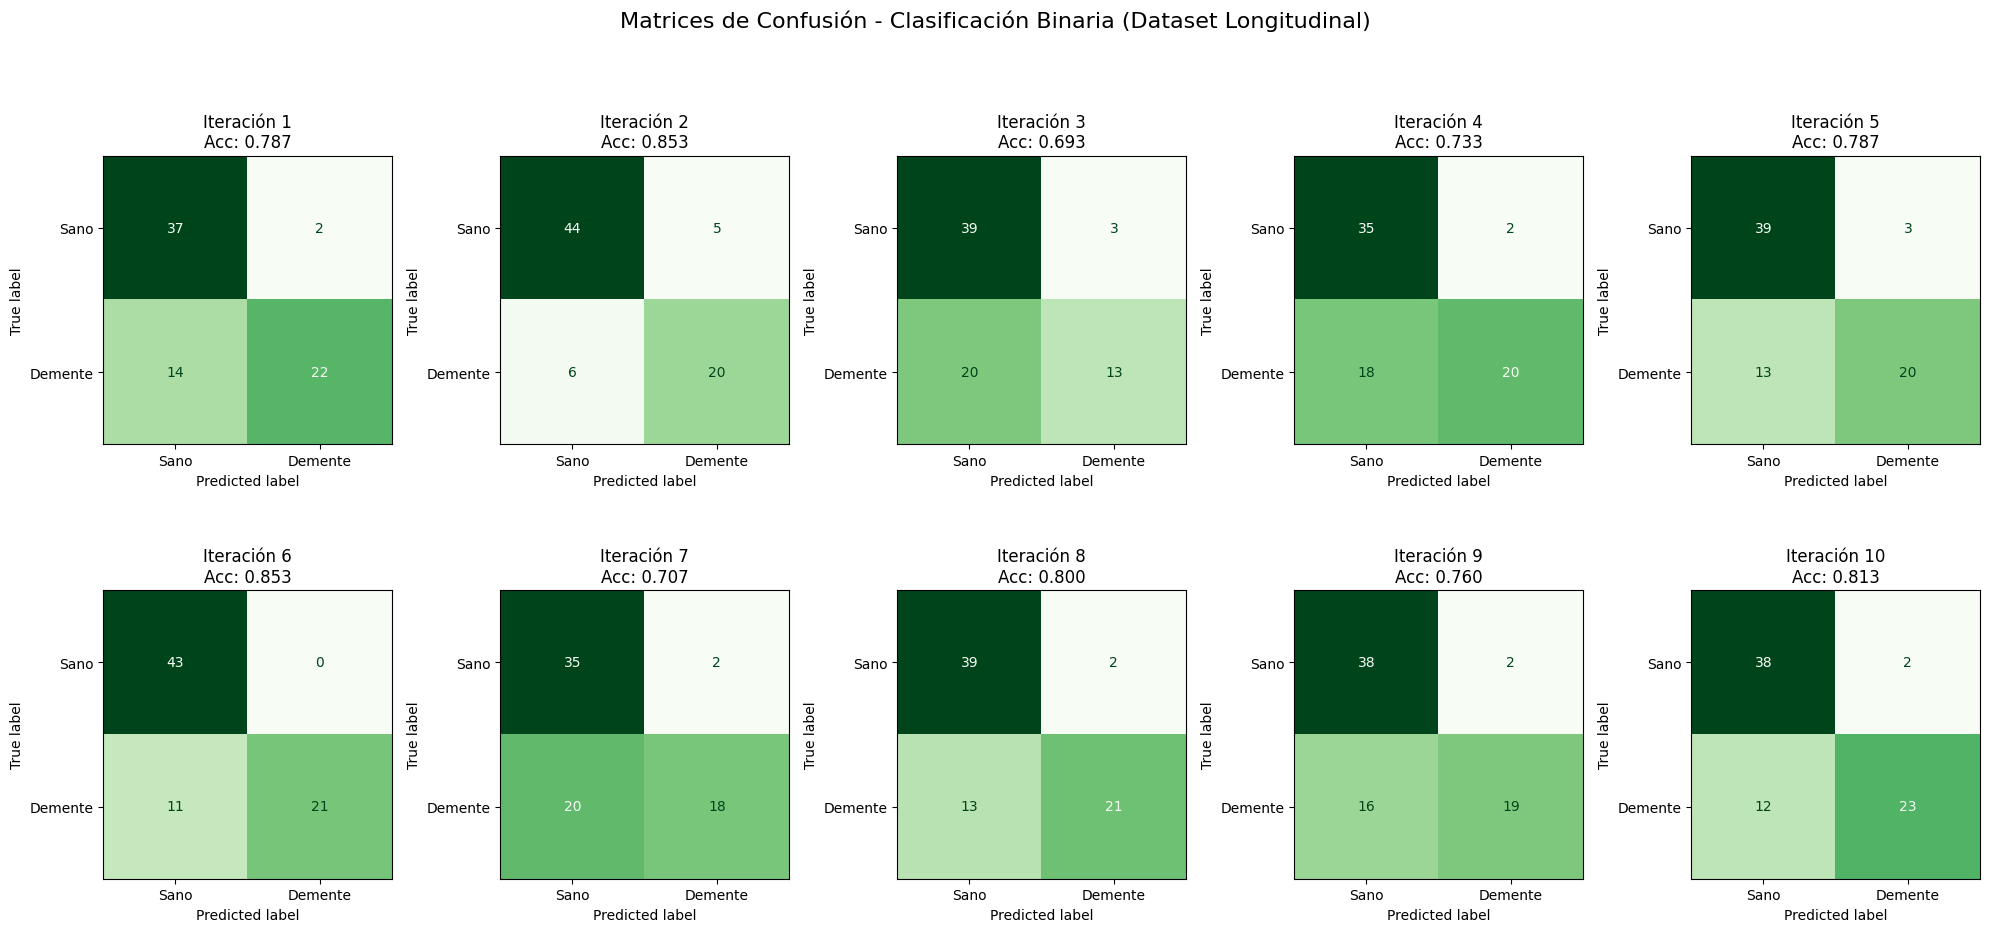

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

# 4. Diseño Experimental: 10 Validaciones Independientes 80/20 [8]
for i in range(10):
    # Partición aleatoria independiente
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # Escalamiento: Ajustado en entreno y aplicado en prueba [7]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo KNN con k=5 [9]
    knn = KNeighborsClassifier(n_neighbors=4)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    
    # Generación y visualización de la matriz en el grid
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Demente'])
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)
    
    # Título por iteración con Accuracy individual
    acc_iter = (y_pred == y_test).mean()
    axes[i].set_title(f"Iteración {i+1}\nAcc: {acc_iter:.3f}")

plt.suptitle("Matrices de Confusión - Clasificación Binaria (Dataset Longitudinal)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
